In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
GITT_exp_orig = pd.read_csv(
    "/mnt/e/pybamm_data/GITT/GITT_25deg_Niall.csv", comment="#", header=None
).to_numpy()
print(np.shape(GITT_exp_orig))

(213520, 4)


In [3]:
pulse_start = np.zeros((24,), dtype=int)
pulse_stop = np.zeros((24,), dtype=int)
j = 0
for i in range(1, 213520):
    if GITT_exp_orig[i,3] == 0 and GITT_exp_orig[i-1,3] != 0:
        pulse_stop[j] = i
        j += 1
    elif GITT_exp_orig[i,3] != 0 and GITT_exp_orig[i-1,3] == 0:
        pulse_start[j] = i
print(pulse_start)
print(pulse_stop)

[     1   9003  18005  27007  36009  45011  54013  63015  72017  81019
  90021  99023 108025 117027 126029 135031 144033 153035 162037 171039
 180041 189043 198045 207047]
[  4802  13804  22806  31808  40810  49812  58814  67816  76818  85820
  94822 103824 112826 121828 130830 139832 148834 157836 166838 175840
 184842 193844 202846 211299]


In [4]:
t_rest_exp = np.zeros((4201,23))
V_rest_exp = np.zeros((4201,23))
for j in range(23):
    a = pulse_stop[j]
    b = pulse_start[j+1]
    t_rest_exp[:,j] = GITT_exp_orig[a:b,0]-GITT_exp_orig[a,0]
    V_rest_exp[:,j] = GITT_exp_orig[a:b,2]
print(np.shape(t_rest_exp))
print(np.shape(V_rest_exp))

(4201, 23)
(4201, 23)


In [ ]:
np.savetxt("GITT_03C_298K_t_rest_exp.txt",t_rest_exp,delimiter=",")
np.savetxt("GITT_03C_298K_V_rest_exp.txt",V_rest_exp,delimiter=",")

In [ ]:
t_rest_exp = np.loadtxt("GITT_03C_298K_t_rest_exp.txt",delimiter=",")
V_rest_exp = np.loadtxt("GITT_03C_298K_V_rest_exp.txt",delimiter=",")

In [5]:
GITT_sim_orig = pd.read_csv(
    "/mnt/e/pybamm_data/GITT/GITT_03C_298K_v4.csv", header=0
).to_numpy()
print(np.shape(GITT_sim_orig))

(103071, 4)


In [9]:
pulse_start = np.zeros((25,), dtype=int)
pulse_stop = np.zeros((25,), dtype=int)
j = 0
for i in range(1, 103071):
    if GITT_sim_orig[i,1] == 0 and GITT_sim_orig[i-1,1] != 0:
        pulse_stop[j] = i
        j += 1
    elif GITT_sim_orig[i,1] != 0 and GITT_sim_orig[i-1,1] == 0:
        pulse_start[j] = i
print(pulse_start)
print(pulse_stop)

[    0  4141  8281 12421 16561 20701 24841 28981 33121 37261 41401 45541
 49681 53821 57961 62101 66241 70381 74521 78661 82801 86941 91081 95221
 99361]
[  481  4621  8761 12901 17041 21181 25321 29461 33601 37741 41881 46021
 50161 54301 58441 62581 66721 70861 75001 79141 83281 87421 91561 95701
 99411]


In [10]:
t_rest_sim = np.zeros((3660,23))
V_rest_sim = np.zeros((3660,23))
for j in range(23):
    a = pulse_stop[j]
    b = pulse_start[j+1]
    t_rest_sim[:,j] = (GITT_sim_orig[a:b,0]-GITT_sim_orig[a,0])*3600
    V_rest_sim[:,j] = GITT_sim_orig[a:b,2]
print(np.shape(t_rest_sim))
print(np.shape(V_rest_sim))

(3660, 23)
(3660, 23)


In [ ]:
np.savetxt("GITT_03C_298K_t_rest_sim.txt",t_rest_sim,delimiter=",")
np.savetxt("GITT_03C_298K_V_rest_sim.txt",V_rest_sim,delimiter=",")

In [ ]:
t_rest_sim = np.loadtxt("GITT_03C_298K_t_rest_sim.txt",delimiter=",")
V_rest_sim = np.loadtxt("GITT_03C_298K_V_rest_sim.txt",delimiter=",")

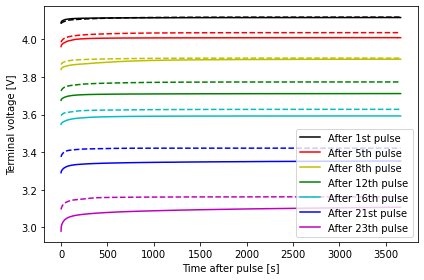

In [13]:
fig, ax = plt.subplots()
ax.plot(t_rest_exp[:,0],V_rest_exp[:,0],color='k',label="After 1st pulse")
ax.plot(t_rest_sim[:,0],V_rest_sim[:,0],color='k',linestyle='dashed')
ax.plot(t_rest_exp[:,4],V_rest_exp[:,4],color='r',label="After 5th pulse")
ax.plot(t_rest_sim[:,4],V_rest_sim[:,4],color='r',linestyle='dashed')
ax.plot(t_rest_exp[:,7],V_rest_exp[:,7],color='y',label="After 8th pulse")
ax.plot(t_rest_sim[:,7],V_rest_sim[:,7],color='y',linestyle='dashed')
ax.plot(t_rest_exp[:,11],V_rest_exp[:,11],color='g',label="After 12th pulse")
ax.plot(t_rest_sim[:,11],V_rest_sim[:,11],color='g',linestyle='dashed')
ax.plot(t_rest_exp[:,15],V_rest_exp[:,15],color='c',label="After 16th pulse")
ax.plot(t_rest_sim[:,15],V_rest_sim[:,15],color='c',linestyle='dashed')
ax.plot(t_rest_exp[:,20],V_rest_exp[:,20],color='b',label="After 21st pulse")
ax.plot(t_rest_sim[:,20],V_rest_sim[:,20],color='b',linestyle='dashed')
ax.plot(t_rest_exp[:,22],V_rest_exp[:,22],color='m',label="After 23th pulse")
ax.plot(t_rest_sim[:,22],V_rest_sim[:,22],color='m',linestyle='dashed')
ax.set_xlabel("Time after pulse [s]")
ax.set_ylabel("Terminal voltage [V]")
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig("/mnt/e/pybamm_data/GITT/GITT_03C_298K_8cycles.pdf")
plt.show()